# Import

In [1]:
import pandas as pd
import numpy as np
from tqdm.auto import tqdm
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


torch.manual_seed(42)
np.random.seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"


/home/nesaulov/study/urfu/coursach/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Read data

сначала я удалил все дубликаты, потом заметил что одним и тем же строкам, соответствовала разная сигма, их объединил в среднее, но когда удалил колоник с временем и сигмой, то опять заметил, что одним и тем же данным могла соответствовать разная температура, и объединил их в медиану. 

In [2]:
df = pd.read_csv('../data/data_clear_2.csv')
# df = df.drop_duplicates().reset_index().drop(columns='index')

df

,Th,C,Cr,Co,Mo,W,Al,Ti,Nb,B,...,S,Si,Mn,P,Hf,Cu,Ge,Ga,Ni,T.K
0,0.0,0.0,2.0,3.0,0.4,5.00,5.7,0.20,0.1,0.0,...,0.0,0.0,0.0,0.0,0.030,0.0,0.0,0.0,67.570,1255.15
1,0.0,0.0,2.0,3.0,0.4,5.00,5.7,0.20,0.1,0.0,...,0.0,0.0,0.0,0.0,0.150,0.0,0.0,0.0,67.450,1173.15
2,0.0,0.0,5.0,0.0,2.0,5.00,5.5,1.00,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.0,69.500,773.15
3,0.0,0.0,5.2,7.5,3.0,8.75,5.3,0.55,0.0,0.0,...,0.0,0.0,0.0,0.0,0.105,0.0,0.0,0.0,60.345,1073.15
4,0.0,0.0,6.0,9.0,0.6,6.00,5.6,1.00,0.0,0.0,...,0.0,0.0,0.0,0.0,0.100,0.0,0.0,0.0,59.700,1273.15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
487,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.500,NaN,NaN,0.2,99.300,1144.26
488,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.500,NaN,NaN,0.5,99.000,1144.26
489,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.500,NaN,NaN,NaN,99.500,1144.26
490,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.750,NaN,NaN,0.2,99.050,1144.26


In [3]:
dups = df[df.duplicated(subset=df.columns.drop("T.K"), keep=False)]
dups = dups.sort_values(list(df.columns))
print(dups)


Empty DataFrame
Columns: [Th, C, Cr, Co, Mo, W, Al, Ti, Nb, B, Fe, Y, Zr, Ta, Re, Ru, V, La, S, Si, Mn, P, Hf, Cu, Ge, Ga, Ni, T.K]
Index: []

[0 rows x 28 columns]


In [4]:
mass = '232,03806	12,011	51,9961	58,933194	95,95	183,84	26,9815385	47,867	92,90637	10,81	55,845	88,90584	91,224	180,94788	186,207	101,07	50,9415	140,116	138,90547	32,06	28,085	54,938044	24,305	30,973761998	178,49	107,8682	63,546	208,9804	207,2	192,22	72,63	69,723	58,6934'.replace(',', '.').split()
element = 'Th	C	Cr	Co	Mo	W	Al	Ti	Nb	B	Fe	Y	Zr	Ta	Re	Ru	V	Ce	La	S	Si	Mn	Mg	P	Hf	Ag	Cu	Bi	Pb	Ir	Ge	Ga	Ni'.split()
atom_mass = dict(zip(element, mass))

In [5]:
atom_mass['Ni']

'58.6934'

# Препроцессинг

In [6]:
# for elem in df.drop(columns=['Sigma, Mpa', 'T.K', 't.h']).columns.to_list():
#     df[elem] = df[elem] / float(atom_mass[elem])
# df['sum'] = df[df.drop(columns=['Sigma, Mpa', 'T.K', 't.h']).columns.to_list()].sum(axis=1, skipna=True)

# cols = df.drop(columns=['Sigma, Mpa', 'T.K', 't.h']).columns
# df.loc[:, cols] = df.loc[:, cols].div(df['sum'], axis=0)
# df.loc[:, cols] = df.loc[:, cols].div(df['Ni'], axis=0)


df = df.fillna(0)

# df = df.drop(columns=['Sigma, Mpa', 't.h', 'Ni', 'sum'])
df

,Th,C,Cr,Co,Mo,W,Al,Ti,Nb,B,...,S,Si,Mn,P,Hf,Cu,Ge,Ga,Ni,T.K
0,0.0,0.0,2.0,3.0,0.4,5.00,5.7,0.20,0.1,0.0,...,0.0,0.0,0.0,0.0,0.030,0.0,0.0,0.0,67.570,1255.15
1,0.0,0.0,2.0,3.0,0.4,5.00,5.7,0.20,0.1,0.0,...,0.0,0.0,0.0,0.0,0.150,0.0,0.0,0.0,67.450,1173.15
2,0.0,0.0,5.0,0.0,2.0,5.00,5.5,1.00,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.0,69.500,773.15
3,0.0,0.0,5.2,7.5,3.0,8.75,5.3,0.55,0.0,0.0,...,0.0,0.0,0.0,0.0,0.105,0.0,0.0,0.0,60.345,1073.15
4,0.0,0.0,6.0,9.0,0.6,6.00,5.6,1.00,0.0,0.0,...,0.0,0.0,0.0,0.0,0.100,0.0,0.0,0.0,59.700,1273.15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
487,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.00,0.0,0.0,...,0.0,0.0,0.0,0.0,0.500,0.0,0.0,0.2,99.300,1144.26
488,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.00,0.0,0.0,...,0.0,0.0,0.0,0.0,0.500,0.0,0.0,0.5,99.000,1144.26
489,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.00,0.0,0.0,...,0.0,0.0,0.0,0.0,0.500,0.0,0.0,0.0,99.500,1144.26
490,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.00,0.0,0.0,...,0.0,0.0,0.0,0.0,0.750,0.0,0.0,0.2,99.050,1144.26


In [7]:
GROUPS = {
    1: ["Co", "Cr", "Fe", "Mo", "W", "Ta", "Re"],       # Solid solution strengtheners
    2: ["W", "Ta", "Ti", "Mo", "Nb", "Hf"],             # Carbide form MC
    3: ["Cr"],                                          # Carbide form M7C3
    4: ["Cr", "Mo", "W"],                               # Carbide form M23C6
    5: ["Mo", "W", "Nb"],                               # Carbide form M6C
    6: ["C", "N"],                                      # Carbonitrides M(CN)
    7: ["Al", "Ti"],                                    # Forms gamma prime Ni3(Al, Ti)
    8: ["Co"],                                          # Raises solvus temperature of gamma prime
    9: ["Al", "Ti", "Nb"],                              # Hardening precipitates/intermetallics
    10: ["Al", "Cr", "Y", "La", "Ce"],                  # Oxidation resistance
    11: ["La", "Th"],                                   # Hot corrosion resistance
    12: ["Cr", "Co", "Si"],                             # Sulfidation resistance
    13: ["B", "Ta"],                                    # Improves creep properties
    14: ["B"],                                          # Increases rupture strength
    15: ["B", "C", "Zr", "Hf"],                         # Grain-boundary refiners
    16: ["Re", "Ru"],                                   # Retards coarsening
}


In [8]:
target_col = 'T.K'

y = df[target_col]
X = df.copy().drop(columns=[target_col])


In [9]:
y_values = df[target_col].values.reshape(-1, 1).astype("float32")
X_values = X.values.astype("float32")

feature_names = list(X.columns)

print("X shape:", X_values.shape)
print("Number of input features:", X_values.shape[1])
print("feature_names:", feature_names)
df

X shape: (492, 27)
Number of input features: 27
feature_names: ['Th', 'C', 'Cr', 'Co', 'Mo', 'W', 'Al', 'Ti', 'Nb', 'B', 'Fe', 'Y', 'Zr', 'Ta', 'Re', 'Ru', 'V', 'La', 'S', 'Si', 'Mn', 'P', 'Hf', 'Cu', 'Ge', 'Ga', 'Ni']


,Th,C,Cr,Co,Mo,W,Al,Ti,Nb,B,...,S,Si,Mn,P,Hf,Cu,Ge,Ga,Ni,T.K
0,0.0,0.0,2.0,3.0,0.4,5.00,5.7,0.20,0.1,0.0,...,0.0,0.0,0.0,0.0,0.030,0.0,0.0,0.0,67.570,1255.15
1,0.0,0.0,2.0,3.0,0.4,5.00,5.7,0.20,0.1,0.0,...,0.0,0.0,0.0,0.0,0.150,0.0,0.0,0.0,67.450,1173.15
2,0.0,0.0,5.0,0.0,2.0,5.00,5.5,1.00,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.0,69.500,773.15
3,0.0,0.0,5.2,7.5,3.0,8.75,5.3,0.55,0.0,0.0,...,0.0,0.0,0.0,0.0,0.105,0.0,0.0,0.0,60.345,1073.15
4,0.0,0.0,6.0,9.0,0.6,6.00,5.6,1.00,0.0,0.0,...,0.0,0.0,0.0,0.0,0.100,0.0,0.0,0.0,59.700,1273.15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
487,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.00,0.0,0.0,...,0.0,0.0,0.0,0.0,0.500,0.0,0.0,0.2,99.300,1144.26
488,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.00,0.0,0.0,...,0.0,0.0,0.0,0.0,0.500,0.0,0.0,0.5,99.000,1144.26
489,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.00,0.0,0.0,...,0.0,0.0,0.0,0.0,0.500,0.0,0.0,0.0,99.500,1144.26
490,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.00,0.0,0.0,...,0.0,0.0,0.0,0.0,0.750,0.0,0.0,0.2,99.050,1144.26


In [10]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X_values,
    y_values,
    test_size=0.30,
    random_state=42,
    shuffle=True
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    shuffle=False
)


In [11]:
scale = True

if scale:
    scaler_X = StandardScaler()
    scaler_y = StandardScaler()

    X_train_scaled = scaler_X.fit_transform(X_train).astype("float32")
    X_val_scaled = scaler_X.transform(X_val).astype("float32")
    X_test_scaled = scaler_X.transform(X_test).astype("float32")

    y_train_scaled = scaler_y.fit_transform(y_train).astype("float32")
    y_val_scaled = scaler_y.transform(y_val).astype("float32")
    y_test_scaled = scaler_y.transform(y_test).astype("float32")
else:
    X_train_scaled = X_train
    X_val_scaled   = X_val
    X_test_scaled  = X_test
    y_train_scaled = y_train
    y_val_scaled   = y_val
    y_test_scaled  = y_test


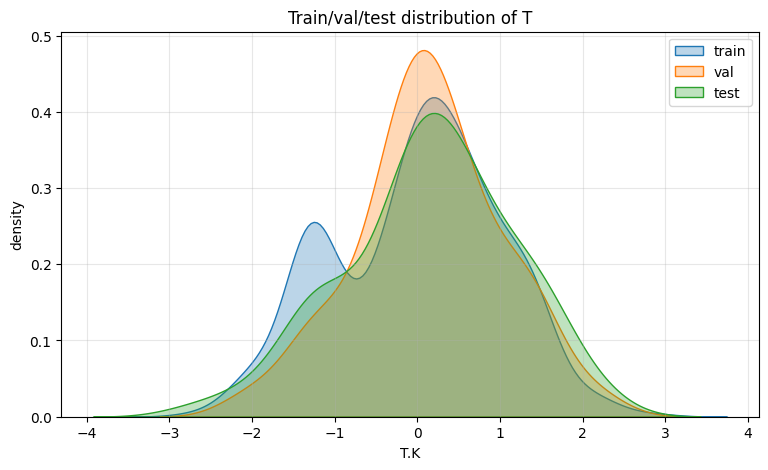

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 5))


sns.kdeplot(y_train_scaled.ravel(), label="train", fill=True, alpha=0.3)
sns.kdeplot(y_val_scaled.ravel(), label="val", fill=True, alpha=0.3)
sns.kdeplot(y_test_scaled.ravel(), label="test", fill=True, alpha=0.3)




plt.xlabel("T.K")
plt.ylabel("density")
plt.title("Train/val/test distribution of T")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# Baseline

In [13]:
def inverse_y(y_scaled, scaler_y):
    return scaler_y.inverse_transform(y_scaled)

def compute_metrics(y_pred, y_true):
    y_pred = y_pred.reshape(-1)
    y_true = y_true.reshape(-1)

    mae = np.mean(np.abs(y_pred - y_true))
    rmse = np.sqrt(np.mean((y_pred - y_true) ** 2))

    rmae_percent = np.mean(np.abs((y_pred - y_true) / y_true)) * 100

    rrmse = rmse / np.mean(y_true)

    return {
        "MAE": mae,
        "RMSE": rmse,
        "RMAE_percent": rmae_percent,
        "RRMSE": rrmse
    }


In [14]:
if scale:
        y_train_orig = inverse_y(y_train_scaled, scaler_y)
        y_val_orig = inverse_y(y_val_scaled, scaler_y)
else:
        y_train_orig = y_train_scaled
        y_val_orig = y_val_scaled


baseline_pred = np.full_like(
    y_val_orig,
    fill_value=y_train_orig.mean()
)

baseline_metrics = compute_metrics(
    baseline_pred,
    y_val_orig
)

baseline_metrics

{'MAE': np.float32(100.15672),
 'RMSE': np.float32(130.03943),
 'RMAE_percent': np.float32(8.583197),
 'RRMSE': np.float32(0.110186614)}

# Сеть

In [15]:
class AlloyDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


In [16]:
batch_size = 16

def train_loader(X_train_scaled, y_train_scaled):
    return DataLoader(
        AlloyDataset(X_train_scaled, y_train_scaled),
        batch_size=batch_size,
        shuffle=True
    )

def val_loader(X_val_scaled, y_val_scaled):
    return DataLoader(
        AlloyDataset(X_val_scaled, y_val_scaled),
        batch_size=batch_size,
        shuffle=False
    )

def test_loader(X_test_scaled, y_test_scaled):
    return DataLoader(
        AlloyDataset(X_test_scaled, y_test_scaled),
        batch_size=batch_size,
        shuffle=False
    )


In [17]:
def build_group_indices(groups, feature_names):
    group_indices = {}

    for group_id, elements in groups.items():
        indices = []

        for el in elements:
            col_name = f"{el}"

            if col_name in feature_names:
                indices.append(feature_names.index(col_name))

        if len(indices) > 0:
            group_indices[group_id] = indices

    return group_indices




In [18]:
group_indices = build_group_indices(GROUPS, feature_names)

for group_id, indices in group_indices.items():
    cols = [feature_names[i] for i in indices]
    print(group_id, cols)


1 ['Co', 'Cr', 'Fe', 'Mo', 'W', 'Ta', 'Re']
2 ['W', 'Ta', 'Ti', 'Mo', 'Nb', 'Hf']
3 ['Cr']
4 ['Cr', 'Mo', 'W']
5 ['Mo', 'W', 'Nb']
6 ['C']
7 ['Al', 'Ti']
8 ['Co']
9 ['Al', 'Ti', 'Nb']
10 ['Al', 'Cr', 'Y', 'La']
11 ['La', 'Th']
12 ['Cr', 'Co', 'Si']
13 ['B', 'Ta']
14 ['B']
15 ['B', 'C', 'Zr', 'Hf']
16 ['Re', 'Ru']


In [19]:
class GroupDifferentiatingBranch(nn.Module):
    def __init__(self, input_indices, hidden_dim):
        super().__init__()

        self.register_buffer(
            "input_indices",
            torch.tensor(input_indices, dtype=torch.long)
        )

        input_dim = len(input_indices)

        self.positive = nn.Linear(input_dim, hidden_dim)
        self.negative = nn.Linear(input_dim, hidden_dim)

        nn.init.constant_(self.positive.bias, 0.5)
        nn.init.constant_(self.negative.bias, -0.5)
        self.positive.bias.requires_grad = False
        self.negative.bias.requires_grad = False


        self.activation = nn.Tanh()

    def forward(self, x):
        # x shape: [batch_size, total_elements]
        x_group = x.index_select(dim=1, index=self.input_indices)

        # direct signal: сумма элементов в группе
        direct = x_group.sum(dim=1, keepdim=True)

        pos = self.activation(self.positive(x_group))
        neg = self.activation(self.negative(x_group))

        # differentiated signal
        diff = pos - neg

        # выход группы
        out = torch.cat(
            [
                direct,
                pos,
                neg,
                diff
            ],
            dim=1
        )

        return out


In [20]:
class DifferentiatingSuperalloyNet(nn.Module):
    def __init__(
        self,
        input_dim,
        group_indices,
        branch_hidden_dim=8,
        head_hidden_dim=64,
    ):
        super().__init__()

        if len(group_indices) == 0:
            raise ValueError(
                "group_indices is empty. "
                "Check feature_names and element column names."
            )

        self.branches = nn.ModuleDict()

        for group_id, indices in group_indices.items():
            self.branches[str(group_id)] = GroupDifferentiatingBranch(
                input_indices=indices,
                hidden_dim=branch_hidden_dim
            )

        one_branch_out_dim = 1 + 3 * branch_hidden_dim
        total_branch_out_dim = len(self.branches) * one_branch_out_dim

        # Важно: добавляем input_dim, потому что будем передавать исходный x напрямую
        head_input_dim = total_branch_out_dim + input_dim

        self.head = nn.Sequential(
            nn.Linear(head_input_dim, head_hidden_dim),
            nn.Tanh(),

            nn.Linear(head_hidden_dim, head_hidden_dim),
            nn.Tanh(),

            nn.Linear(head_hidden_dim, 1)
        )

    def forward(self, x):
        branch_outputs = []

        for branch in self.branches.values():
            branch_outputs.append(branch(x))

        grouped_signal = torch.cat(branch_outputs, dim=1)

        # direct + differentiating signal
        combined = torch.cat([x, grouped_signal], dim=1)

        out = self.head(combined)

        return out


# Train

In [21]:
def train_one_model(
    model,
    train_loader,
    val_loader,
    lr=1e-3,
    weight_decay=1e-5,
    max_epochs=1000,
    patience=80,
    device="cpu"
):
    model = model.to(device)

    criterion = nn.MSELoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    best_val_loss = float("inf")
    best_state = None
    patience_counter = 0

    history = {
        "train_loss": [],
        "val_loss": []
    }

    for epoch in tqdm(range(max_epochs), desc='training', leave=False):
        model.train()
        train_losses = []

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()

            pred = model(xb)
            loss = criterion(pred, yb)

            loss.backward()
            optimizer.step()

            train_losses.append(loss.item())

        train_loss = np.mean(train_losses)

        model.eval()
        val_losses = []

        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(device)
                yb = yb.to(device)

                pred = model(xb)
                loss = criterion(pred, yb)

                val_losses.append(loss.item())

        val_loss = np.mean(val_losses)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            break

    model.load_state_dict(best_state)

    return model, best_val_loss, history


In [22]:
def predict_scaled(model, loader, device="cpu"):
    model.eval()

    preds = []
    targets = []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)

            pred = model(xb).cpu().numpy()

            preds.append(pred)
            targets.append(yb.numpy())

    preds = np.vstack(preds)
    targets = np.vstack(targets)

    return preds, targets

# Training

In [23]:
input_dim = X_train_scaled.shape[1]

results = []

for branch_hidden_dim in tqdm(range(4, 20), desc="Hidden dim search"):
    torch.manual_seed(42)
    np.random.seed(42)

    model = DifferentiatingSuperalloyNet(
        input_dim=input_dim,
        group_indices=group_indices,
        branch_hidden_dim=branch_hidden_dim,
        head_hidden_dim=32,
    )

    model, best_val_loss, history = train_one_model(
        model=model,
        train_loader=train_loader(X_train_scaled, y_train_scaled),
        val_loader=val_loader(X_val_scaled, y_val_scaled),
        lr=1e-3,
        weight_decay=1e-5,
        max_epochs=100,
        device=device
    )

    y_val_pred_scaled, y_val_true_scaled = predict_scaled(
        model,
        val_loader(X_val_scaled, y_val_scaled),
        device=device
    )

    if scale:
        y_val_pred = inverse_y(y_val_pred_scaled, scaler_y)
        y_val_true = inverse_y(y_val_true_scaled, scaler_y)
    else:
        y_val_pred = y_val_pred_scaled
        y_val_true = y_val_true_scaled

    val_metrics = compute_metrics(y_val_pred, y_val_true)

    result = {
        "branch_hidden_dim": branch_hidden_dim,
        "best_val_loss_scaled": best_val_loss,
        **val_metrics
    }

    results.append(result)

    print(
        f"branch_hidden={branch_hidden_dim:2d} | "
        f"MAE={val_metrics['MAE']:.3f} | "
        f"RMSE={val_metrics['RMSE']:.3f} | "
        f"RMAE={val_metrics['RMAE_percent']:.2f}% | "
        f"RRMSE={val_metrics['RRMSE']:.4f}"
    )


Hidden dim search:   6%|▋         | 1/16 [00:17<04:24, 17.65s/it]

branch_hidden= 4 | MAE=47.959 | RMSE=77.229 | RMAE=3.95% | RRMSE=0.0654


Hidden dim search:  12%|█▎        | 2/16 [00:30<03:30, 15.01s/it]

branch_hidden= 5 | MAE=48.492 | RMSE=80.437 | RMAE=4.00% | RRMSE=0.0682


Hidden dim search:  19%|█▉        | 3/16 [00:46<03:17, 15.18s/it]

...

branch_hidden=17 | MAE=47.255 | RMSE=76.632 | RMAE=3.89% | RRMSE=0.0649


Hidden dim search:  94%|█████████▍| 15/16 [03:33<00:14, 14.98s/it]

branch_hidden=18 | MAE=44.795 | RMSE=70.925 | RMAE=3.70% | RRMSE=0.0601


Hidden dim search: 100%|██████████| 16/16 [03:48<00:00, 14.31s/it]

branch_hidden=19 | MAE=45.471 | RMSE=76.491 | RMAE=3.74% | RRMSE=0.0648


In [24]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values("RMAE_percent")

results_df

,branch_hidden_dim,best_val_loss_scaled,MAE,RMSE,RMAE_percent,RRMSE
3,7,0.249503,42.975975,73.656662,3.565606,0.062412
4,8,0.246389,44.060013,72.998840,3.587681,0.061854
12,16,0.278668,43.606106,76.525299,3.605043,0.064842
9,13,0.214440,44.377026,67.717087,3.662515,0.057379
14,18,0.242596,44.794685,70.924835,3.698696,0.060097
5,9,0.254244,44.644249,74.215912,3.722654,0.062886
8,12,0.253592,44.941757,73.843124,3.730690,0.062570
15,19,0.269589,45.471291,76.491013,3.742490,0.064813
7,11,0.246193,46.208698,72.586296,3.835355,0.061505
6,10,0.263978,46.338531,75.716850,3.835983,0.064157


In [25]:
best_branch_hidden_dim = int(results_df.iloc[0]["branch_hidden_dim"])

print("Best branch_hidden_dim:", best_branch_hidden_dim)


Best branch_hidden_dim: 7


# Best model

In [26]:
best_model = DifferentiatingSuperalloyNet(
    input_dim=input_dim,
    group_indices=group_indices,
    branch_hidden_dim=best_branch_hidden_dim,
    head_hidden_dim=8,
)

best_model, best_val_loss, best_history = train_one_model(
    model=best_model,
    train_loader=train_loader(X_train_scaled, y_train_scaled),
    val_loader=val_loader(X_val_scaled, y_val_scaled),
    lr=1e-3,
    weight_decay=1e-5,
    max_epochs=1000,
    device=device
)


## предсказание на тесте

In [27]:
y_test_pred_scaled, y_test_true_scaled = predict_scaled(
    best_model,
    test_loader(X_test_scaled, y_test_scaled),
    device=device
)

y_test_pred = inverse_y(y_test_pred_scaled, scaler_y)
y_test_true = inverse_y(y_test_true_scaled, scaler_y)

test_metrics = compute_metrics(y_test_pred, y_test_true)

test_metrics


{'MAE': np.float32(60.23462),
 'RMSE': np.float32(96.49954),
 'RMAE_percent': np.float32(5.3244905),
 'RRMSE': np.float32(0.08180811)}

## худшие предсказания

In [28]:
pred_df = pd.DataFrame({
    "y_true": y_test_true.reshape(-1),
    "y_pred": y_test_pred.reshape(-1),
    "abs_error": np.abs(y_test_pred.reshape(-1) - y_test_true.reshape(-1)),
    "rel_error_percent": np.abs(
        (y_test_pred.reshape(-1) - y_test_true.reshape(-1)) 
        / y_test_true.reshape(-1)
    ) * 100
})

pred_df = pred_df.sort_values("rel_error_percent", ascending=False)

pred_df.head(10)


,y_true,y_pred,abs_error,rel_error_percent
19,773.150024,1191.205811,418.055786,54.071754
56,973.150024,1285.830078,312.680054,32.130714
71,1023.150024,1224.656250,201.506226,19.694691
15,1373.150024,1154.061157,219.088867,15.955202
48,1143.150024,967.366028,175.783997,15.377159
30,1423.150024,1212.644409,210.505615,14.791528
72,1123.150024,1278.676880,155.526855,13.847381
18,1373.150024,1215.818359,157.331665,11.457719
57,1023.150024,1134.101562,110.951538,10.844112
12,1130.369995,1249.009766,118.639771,10.495658


# Проверка результатов

## Кроссвалидация

Число нейронов почти не влияло на качество, поэтому была выбрана более простая архитектура с best_branch_hidden_dim нейронами.
Так как у нас задача регрессии и она неравномерная, то буде разумно сделать фолды по бинам.

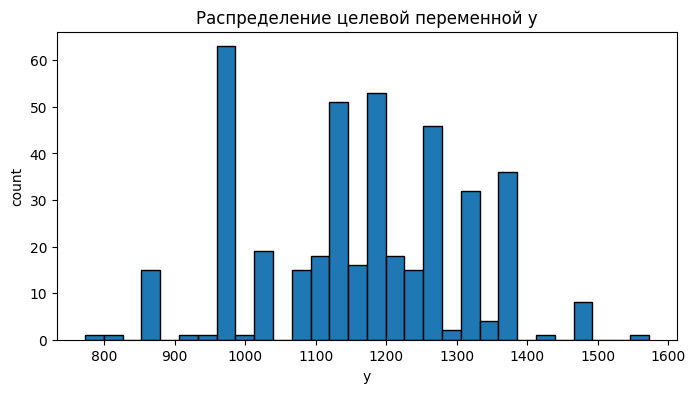

In [29]:
X_kfold = np.concat([X_train, X_val])
y_kfold = np.concat([y_train, y_val])


plt.figure(figsize=(8, 4))
plt.hist(y_kfold, bins=30, edgecolor="black")
plt.xlabel("y")
plt.ylabel("count")
plt.title("Распределение целевой переменной y")
plt.show()

In [30]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

y_bins = pd.qcut(y_kfold.ravel(), q=10, labels=False, duplicates="drop")
results_crossval = []
neiron = best_branch_hidden_dim

for i, (train_index, val_index) in enumerate(skf.split(X_kfold, y_bins)):
    input_dim = X_kfold.shape[1]
    X_train = X_kfold[train_index]
    y_train = y_kfold[train_index]
    X_val = X_kfold[val_index]
    y_val = y_kfold[val_index]


    scaler_X = StandardScaler()
    scaler_y = StandardScaler()
    X_train_scaled = scaler_X.fit_transform(X_train)
    X_val_scaled = scaler_X.transform(X_val)
    y_train_scaled = scaler_y.fit_transform(y_train)
    y_val_scaled = scaler_y.transform(y_val)

    input_dim = X_train_scaled.shape[1]
    model = DifferentiatingSuperalloyNet(
            input_dim=input_dim,
            group_indices=group_indices,
            branch_hidden_dim=neiron,
            head_hidden_dim=8,
        )

    model, best_val_loss, history = train_one_model(
        model=model,
        train_loader=train_loader(X_train_scaled, y_train_scaled),
        val_loader=val_loader(X_val_scaled, y_val_scaled),
        lr=1e-3,
        weight_decay=1e-5,
        max_epochs=100,
        patience=80,
        device=device
    )

    y_val_pred_scaled, y_val_true_scaled = predict_scaled(
        model,
        val_loader(X_val_scaled, y_val_scaled),
        device=device
    )

    if scale:
        y_val_pred = inverse_y(y_val_pred_scaled, scaler_y)
        y_val_true = inverse_y(y_val_true_scaled, scaler_y)
    else:
        y_val_pred = y_val_pred_scaled
        y_val_true = y_val_true_scaled

    val_metrics = compute_metrics(y_val_pred, y_val_true)

    result = {
        **val_metrics
    }

    results_crossval.append(result)

        


In [31]:
for i, (_, val_index) in enumerate(skf.split(X_kfold, y_bins)):
    y_val_fold = y_kfold[val_index]

    print(f"Fold {i + 1}")
    print("mean:", y_val_fold.mean())
    print("median:", np.median(y_val_fold))
    print("min:", y_val_fold.min())
    print("max:", y_val_fold.max())
    print()


Fold 1
mean: 1166.3628
median: 1189.0
min: 866.48
max: 1572.039

Fold 2
mean: 1161.7698
median: 1189.0
min: 866.48
max: 1373.15

Fold 3
mean: 1165.6995
median: 1189.0
min: 866.48
max: 1473.15

Fold 4
mean: 1163.587
median: 1172.039
min: 773.15
max: 1473.15

Fold 5
mean: 1157.9108
median: 1189.0
min: 823.15
max: 1473.15



In [32]:
results_crossval_df = pd.DataFrame(results_crossval)
results_crossval_df = results_crossval_df.sort_values("RMAE_percent", ascending=False)

results_crossval_df

,MAE,RMSE,RMAE_percent,RRMSE
3,67.813988,107.054985,5.973325,0.092004
1,59.272182,93.909851,5.302212,0.080833
0,50.874866,93.895348,4.358023,0.080503
2,46.608143,79.971146,3.979598,0.068604
4,44.844631,76.757309,3.958802,0.066289


In [33]:
# медиана по каждому числовому столбцу
median_values = results_crossval_df.median()

# дисперсия по каждому числовому столбцу
variance_values = results_crossval_df.var()

print("Медиана:")
print(median_values)

print("\nДисперсия:")
print(variance_values)


Медиана:
MAE             50.874866
RMSE            93.895348
RMAE_percent     4.358023
RRMSE            0.080503
dtype: float32

Дисперсия:
MAE              91.695061
RMSE            149.193802
RMAE_percent      0.792071
RRMSE             0.000109
dtype: float32


## Bootstrap

In [34]:
results_bootstrap = []
rng = np.random.default_rng(42)

n = len(y_test)
n_bootstrap = 3000

mae_scores = []
rmse_scores = []
rmae_scores = []
rrmse_scores = []

def ci(scores):
    low, median, high = np.percentile(scores, [2.5, 50, 97.5])
    return {
        "median": median,
        "ci_low": low,
        "ci_high": high
    }


for _ in range(n_bootstrap):
    indices = rng.choice(n, size=n, replace=True)

    y_true_sample = y_test_true[indices]
    y_pred_sample = y_test_pred[indices]

    val_metrics = compute_metrics(y_pred_sample, y_true_sample)

    mae_scores.append(val_metrics["MAE"])
    rmse_scores.append(val_metrics["RMSE"])
    rmae_scores.append(val_metrics["RMAE_percent"])
    rrmse_scores.append(val_metrics["RRMSE"])


    results_bootstrap.append(
        {
        "MAE": ci(mae_scores),
        "RMSE": ci(rmse_scores),
        "RMAE_percent": ci(rmae_scores),
        "RRMSE": ci(rrmse_scores),
        }
    )
print(results_bootstrap)

[{'MAE': {'median': np.float64(60.61662673950195), 'ci_low': np.float64(60.61662673950195), 'ci_high': np.float64(60.61662673950195)}, 'RMSE': {'median': np.float64(94.26490020751953), 'ci_low': np.float64(94.26490020751953), 'ci_high': np.float64(94.26490020751953)}, 'RMAE_percent': {'median': np.float64(5.370637893676758), 'ci_low': np.float64(5.370637893676758), 'ci_high': np.float64(5.370637893676758)}, 'RRMSE': {'median': np.float64(0.07991763949394226), 'ci_low': np.float64(0.07991763949394226), 'ci_high': np.float64(0.07991763949394226)}}, {'MAE': {'median': np.float64(60.70919609069824), 'ci_low': np.float64(60.621255207061765), 'ci_high': np.float64(60.79713697433472)}, 'RMSE': {'median': np.float64(91.88860321044922), 'ci_low': np.float64(89.63112106323243), 'ci_high': np.float64(94.14608535766601)}, 'RMAE_percent': {'median': np.float64(5.2567222118377686), 'ci_low': np.float64(5.148502314090729), 'ci_high': np.float64(5.364942109584808)}, 'RRMSE': {'median': np.float64(0.07

In [35]:
results_bootstrap_df = pd.DataFrame(results_bootstrap)
df_bootstrap = pd.json_normalize(results_bootstrap, sep="_")


df_bootstrap.head()

,MAE_median,MAE_ci_low,MAE_ci_high,RMSE_median,RMSE_ci_low,RMSE_ci_high,RMAE_percent_median,RMAE_percent_ci_low,RMAE_percent_ci_high,RRMSE_median,RRMSE_ci_low,RRMSE_ci_high
0,60.616627,60.616627,60.616627,94.264900,94.264900,94.264900,5.370638,5.370638,5.370638,0.079918,0.079918,0.079918
1,60.709196,60.621255,60.797137,91.888603,89.631121,94.146085,5.256722,5.148502,5.364942,0.077226,0.074669,0.079783
2,60.801765,60.625884,76.324030,94.264900,89.749936,122.593407,5.370638,5.154198,7.168834,0.079918,0.074804,0.105236
3,65.618694,60.630512,76.638089,99.319786,89.868751,122.606153,5.765008,5.159894,7.180669,0.083623,0.074938,0.105126
4,62.295391,60.635141,76.470454,94.264900,87.940993,122.113410,5.378632,5.165590,7.153067,0.079918,0.074629,0.104645


In [36]:
def bootstrap_plot(input, name):
    scores = input

    low, median, high = np.percentile(scores, [2.5, 50, 97.5])

    plt.figure(figsize=(7, 4))
    plt.hist(scores, bins=40, alpha=0.7, edgecolor="black")

    plt.axvline(low, color="red", linestyle="--", label=f"2.5% = {low:.2f}")
    plt.axvline(median, color="black", linestyle="-", label=f"median = {median:.2f}")
    plt.axvline(high, color="red", linestyle="--", label=f"97.5% = {high:.2f}")

    plt.title(f"Bootstrap distribution of {name}")
    plt.xlabel(name)
    plt.ylabel("Count")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


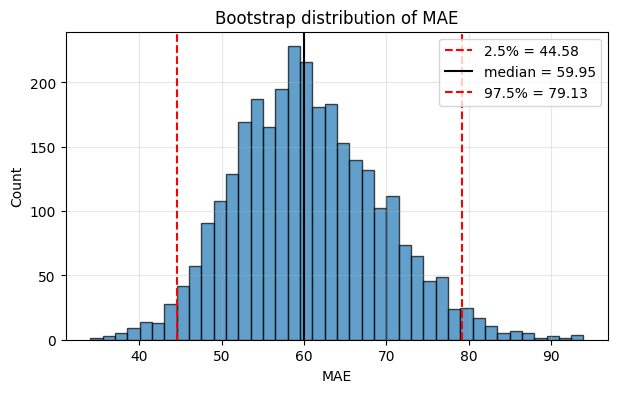

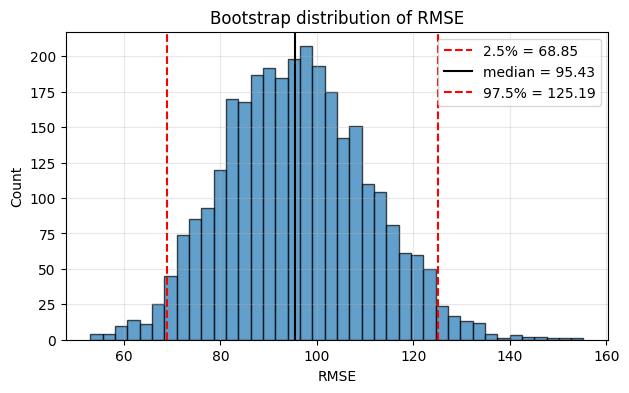

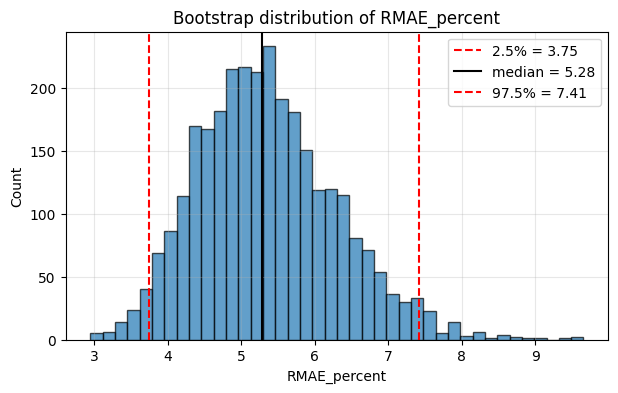

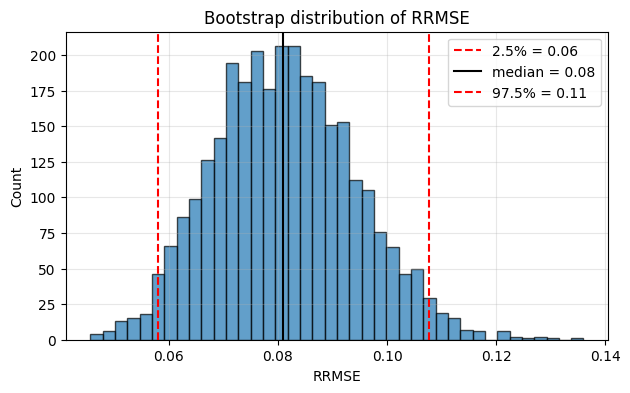

In [37]:
bootstrap_plot(mae_scores, "MAE")
bootstrap_plot(rmse_scores, "RMSE")
bootstrap_plot(rmae_scores, "RMAE_percent")
bootstrap_plot(rrmse_scores, "RRMSE")

## Анализ остатков

### True vs Predicted

Модель в целом улавливает зависимость: точки примерно идут вдоль красной линии.

Но видно, что предсказания как будто сжаты к диапазону примерно 950–1320:

маленькие истинные значения модель часто завышает;
большие истинные значения модель часто занижает;
крайние значения предсказываются хуже.
То есть модель неплохо работает в среднем диапазоне, но хуже на краях.

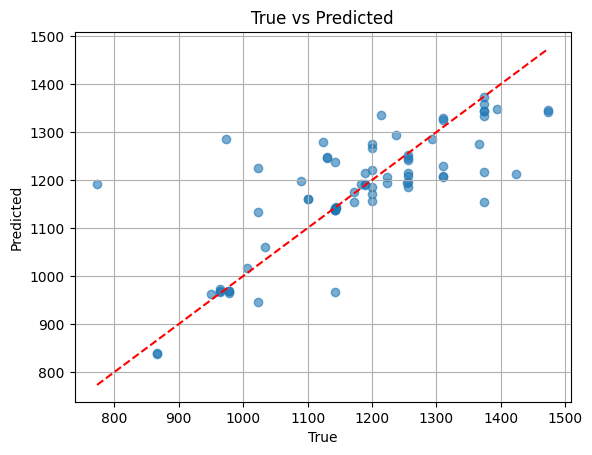

In [38]:
plt.scatter(y_test_true, y_test_pred, alpha=0.6)
plt.plot([min(y_test_true), max(y_test_true)], [min(y_test_true), max(y_test_true)], 'r--')
plt.xlabel("True")
plt.ylabel("Predicted")
plt.title("True vs Predicted")
plt.grid()
plt.show()


### Residuals vs Predicted

Остатки в основном расположены вокруг нуля, но разброс довольно большой.

Есть несколько заметных выбросов:

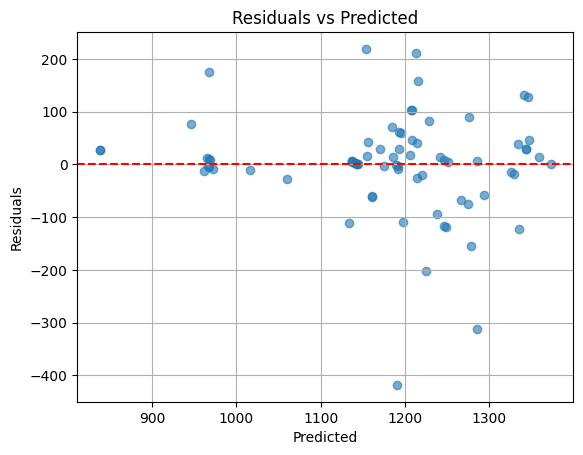

In [39]:
residuals = y_test_true - y_test_pred
plt.scatter(y_test_pred, residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted")
plt.grid()
plt.show()


### Residual Distribution

Распределение остатков в целом сосредоточено около нуля, это хорошо.

Но есть:

* длинные хвосты;
* выбросы слева и справа;
* небольшая асимметрия.

Это значит, что модель обычно ошибается умеренно, но иногда даёт крупные ошибки.

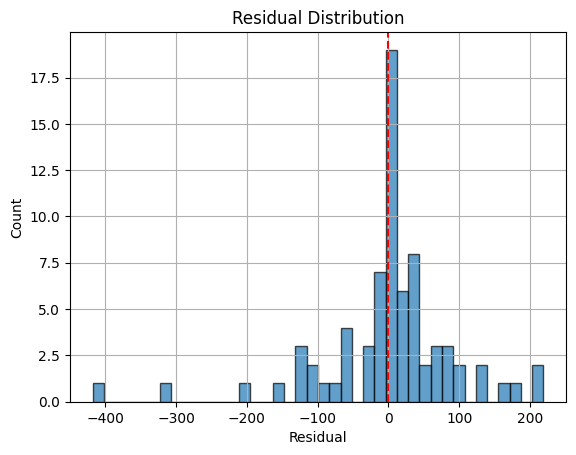

In [40]:
plt.hist(residuals, bins=40, edgecolor="black", alpha=0.7)
plt.axvline(0, color='red', linestyle='--')
plt.xlabel("Residual")
plt.ylabel("Count")
plt.title("Residual Distribution")
plt.grid()
plt.show()


# Вывод

Общий вывод
Модель работает адекватно в среднем диапазоне значений, но:

хуже предсказывает крайние значения;
есть выбросы с большими ошибками;
предсказания немного стремятся к среднему значению.
То есть качество выглядит нормальным, но модель может недооценивать большие значения и переоценивать маленькие.

# доп проверка схожести теста и тренировки

In [41]:
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
import numpy as np

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

NN = NearestNeighbors(n_neighbors=1, metric="euclidean")
NN.fit(X_train)

distances, indices = NN.kneighbors(X_test)

print(distances[:10])


[[3.93262684e-01]
 [4.67533410e-01]
 [9.32633781e+00]
 [5.34330904e-01]
 [8.86834383e-01]
 [3.94087166e-01]
 [8.82804692e-01]
 [1.58612279e-03]
 [4.05142844e-01]
 [1.76726386e-01]]


In [42]:
threshold = 0.01

similar_test_idx = np.where(distances.ravel() < threshold)[0]

print("Похожих test объектов:", len(similar_test_idx))


Похожих test объектов: 5


In [43]:
for i in similar_test_idx[:10]:
    train_i = indices[i][0]
    print("test index:", i, "nearest train index:", train_i, "distance:", distances[i][0])


test index: 7 nearest train index: 274 distance: 0.0015861227875575423
test index: 32 nearest train index: 107 distance: 0.0
test index: 40 nearest train index: 323 distance: 0.0
test index: 62 nearest train index: 149 distance: 0.0
test index: 73 nearest train index: 180 distance: 0.0


In [44]:
X_test.shape

(74, 27)

In [45]:
dups = df[df.duplicated(subset=df.columns.drop("T.K"), keep=False)]
dups = dups.sort_values(list(df.columns))
print(dups)


      Th     C    Cr    Co   Mo    W    Al   Ti   Nb      B  ...    S    Si  \
64   0.0  0.00  10.0   5.0  0.0  4.0  5.00  1.5  0.0  0.000  ...  0.0  0.00   
454  0.0  0.00  10.0   5.0  0.0  4.0  5.00  1.5  0.0  0.000  ...  0.0  0.00   
65   0.0  0.00  12.0   5.0  1.0  4.0  4.00  4.4  0.0  0.000  ...  0.0  0.00   
460  0.0  0.00  12.0   5.0  1.0  4.0  4.00  4.4  0.0  0.000  ...  0.0  0.00   
94   0.0  0.02  17.0  28.4  3.4  1.9  1.03  3.1  1.1  0.016  ...  6.0  0.05   
95   0.0  0.02  17.0  28.4  3.4  1.9  1.03  3.1  1.1  0.016  ...  6.0  0.05   

       Mn    P   Hf    Cu   Ge   Ga      Ni       T.K  
64   0.00  0.0  0.0  0.00  0.0  0.0  62.500  1033.150  
454  0.00  0.0  0.0  0.00  0.0  0.0  62.500  1199.817  
65   0.00  0.0  0.0  0.00  0.0  0.0  67.600  1023.150  
460  0.00  0.0  0.0  0.00  0.0  0.0  67.600  1123.150  
94   0.05  0.0  0.0  0.02  0.0  0.0  33.904  1005.372  
95   0.05  0.0  0.0  0.02  0.0  0.0  33.904  1005.372  

[6 rows x 28 columns]
